In [1]:
# Import operating system utilities for file handling.
import os

# Import NumPy for numerical operations.
import numpy as np

# Import Matplotlib for plotting and visualization.
import matplotlib.pyplot as plt

# Import TensorFlow for building and training models.
import tensorflow as tf

# Import ImageDataGenerator for loading and augmenting images.
from tensorflow.keras.preprocessing.image import ImageDataGenerator

I0000 00:00:1777171300.497250   44439 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777171300.725736   44439 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777171305.413142   44439 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# Define the path to the training dataset directory.
TRAIN_DIR = "./../data/train"

# Define the path to the validation dataset directory.
VAL_DIR = "./../data/validation"

# Set the target image size for resizing all images.
IMG_SIZE = (224, 224)

# Define the number of images processed per batch.
BATCH_SIZE = 32

In [3]:
# Create a data generator for training with augmentation.
# This rescales pixel values and applies random transformations
# such as rotation, zoom, and horizontal flipping.
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Create a data generator for validation without augmentation.
# Only rescaling is applied to keep validation data consistent.
val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [4]:
# Load training images from the directory structure.
# Images are resized and grouped into batches automatically.
# Labels are assigned based on folder names.
train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 1998 images belonging to 2 classes.
Found 501 images belonging to 2 classes.


In [5]:
# Print the mapping of class names to numeric labels.
print("Class indices:", train_data.class_indices)

Class indices: {'benign': 0, 'malignant': 1}


In [6]:
# Retrieve one batch of images and labels from training data.
images, labels = next(train_data)

# Print the shape of the image batch.
print("Image batch shape:", images.shape)

# Print the shape of the label batch.
print("Label batch shape:", labels.shape)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 2)


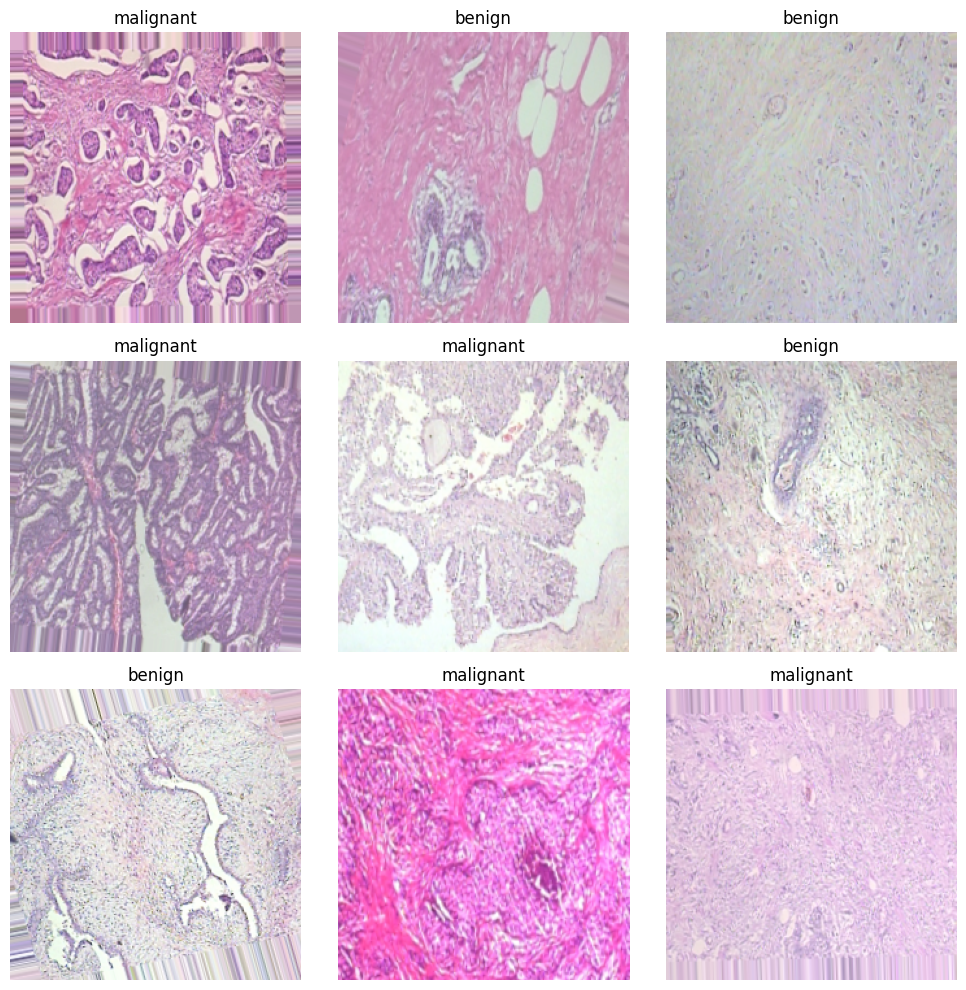

In [7]:
# Create a figure for displaying sample images.
plt.figure(figsize=(10, 10))

# Get the names of the classes (labels) directly from the dataset
# folders so they always match how the model is labeling the images
# (e.g., benign, malignant).
class_names = list(train_data.class_indices.keys())

# Loop through the first nine images in the batch.
for i in range(9):
    plt.subplot(3, 3, i+1)

    # Display the image.
    plt.imshow(images[i])

    # Convert the one-hot encoded label (e.g., [0, 1, 0]) into a single
    # class index.
    # np.argmax() finds the position of the highest value (the "1"),
    # which corresponds to the predicted/true class (e.g., 1 -> malignant).
    label_index = np.argmax(labels[i])

    # Use the class index to retrieve the human-readable class name
    # (e.g., "malignant") from the class_names list, and set it as
    # the title of the image.
    plt.title(class_names[label_index])

    # Remove axis ticks for cleaner visualization.
    plt.axis('off')

# Adjust layout to prevent overlap.
plt.tight_layout()

# Show the plotted images.
plt.show()

In [8]:
# Define a function to count images in each class folder.
def count_images(folder):
    total = 0

    # Iterate through each class directory.
    for class_name in os.listdir(folder):
        class_path = os.path.join(folder, class_name)

        # Check if the path is a directory.
        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))

            # Print the number of images in the class.
            print(f"{class_name}: {count}")

            total += count

    # Print the total number of images in the dataset.
    print("Total:", total)


# Display class distribution for training data.
print("Train Data:")
count_images(TRAIN_DIR)

# Display class distribution for validation data.
print("\nValidation Data:")
count_images(VAL_DIR)

Train Data:
malignant: 1371
benign: 626
Total: 1997

Validation Data:
malignant: 344
benign: 157
Total: 501


In [9]:
# Retrieve a batch from validation data for sanity checking.
sample_batch = next(val_data)
sample_images, sample_labels = sample_batch

# Print the minimum and maximum pixel values.
# Values should be between 0 and 1 after normalization.
print("Sample image min/max:",
      np.min(sample_images),
      np.max(sample_images))

Sample image min/max: 0.003921569 1.0
